# 10. キャップストーン — 1 つの振動を、3 つのレンズで見る

| 層 | セクション |
|---|---|
| Basic | 1. Big Picture / 2. Problem |
| Applied | 3. 解析レンズ 〜 5. 幾何レンズ |
| Advanced | 6. 統合 / 7. 非線形では何が崩れるか / 8. Advanced Notes |

## 1. Big Picture

本書で扱った道具 — 固有値、数値解法、相図 — は別々の技法に見えますが、
**同じ一つの構造の別の顔** です。それを、**減衰する振動** という一つの現象を
**3 通り** に解いて確かめます。

- **解析レンズ**(03 章): $\dot{\mathbf{x}} = A\mathbf{x}$ を固有値分解し、各モードを独立に進める。
- **数値レンズ**(06 章): 公式を使わず RK4 で刻む。誤差が刻み幅の 4 乗で減ることまで確認する。
- **幾何レンズ**(04 章): 解かずに、ベクトル場と固有値の位置だけから「原点に渦を巻いて落ちる」と読む。

3 つが同じ答えを返すこと、そして **一致の理由がすべて $A$ の固有値にある** ことを見ます。
最後に、非線形にしたとき **どのレンズが壊れ、どのレンズが生き残るか** を確かめます。

In [1]:
# Shared setup. Make the book package importable whether or not it is pip-installed,
# then fix the random seed and tidy NumPy printing.
import sys
from pathlib import Path

try:
    import ode_book  # noqa: F401
except ModuleNotFoundError:
    for _base in (Path.cwd(), *Path.cwd().parents):
        if (_base / "src" / "ode_book").is_dir():
            sys.path.insert(0, str(_base / "src"))
            break

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
np.set_printoptions(precision=4, suppress=True)

In [2]:
from ode_book import systems, solvers, plotting
from scipy.linalg import expm
import numpy as np

# One setup shared by all three lenses: a damped oscillator
#   x'' + 2 gamma x' + omega^2 x = 0,  written as dx/dt = A x with x = [position, velocity].
omega, gamma = 2.0, 0.3
A = np.array([[0.0, 1.0], [-(omega**2), -2.0 * gamma]])
x0 = np.array([1.0, 0.0])          # released from rest at position 1
t_end = 10.0
t = np.linspace(0.0, t_end, 601)

## 2. Problem

$\omega = 2$, $\gamma = 0.3$ の振動子を、位置 $1$・速度 $0$ から放す。
**$t = 10$ での状態 $(x, v)$ を求めよ** —— を、3 つのレンズで独立に解き、突き合わせます。

行列で書くと

$$
\frac{d}{dt}\begin{pmatrix} x \\ v \end{pmatrix}
= \underbrace{\begin{pmatrix} 0 & 1 \\ -\omega^2 & -2\gamma \end{pmatrix}}_{A}
\begin{pmatrix} x \\ v \end{pmatrix}.
$$

## 3. 解析レンズ — 固有値分解して、モードごとに進める

$A$ の固有値 $\lambda_{1,2}$ と固有ベクトル $\mathbf{v}_{1,2}$ を取り、初期値を固有基底で表すと

$$
\mathbf{x}(t) = c_1 e^{\lambda_1 t}\mathbf{v}_1 + c_2 e^{\lambda_2 t}\mathbf{v}_2,
\qquad \mathbf{c} = V^{-1}\mathbf{x}_0 .
$$

**各モードは互いに干渉せず、独立に $e^{\lambda t}$ で進む** — これが対角化のご利益です。
ここでは $\lambda = -\gamma \pm i\sqrt{\omega^2-\gamma^2}$ という複素共役ペアになり、
実部が減衰率、虚部が角振動数を与えます。

In [3]:
# Lens 1: diagonalize, advance each mode independently, recombine.
evals, V = np.linalg.eig(A)
c = np.linalg.solve(V, x0)
X_exact = np.real(V @ (np.exp(np.outer(evals, t)) * c[:, None]))   # shape (2, len(t))

print("eigenvalues     :", np.round(evals, 4))
print("predicted -gamma +/- i sqrt(omega^2 - gamma^2):",
      np.round([-gamma + 1j * np.sqrt(omega**2 - gamma**2),
                -gamma - 1j * np.sqrt(omega**2 - gamma**2)], 4))
print("decay rate      : Re(lambda) =", round(float(evals[0].real), 4),
      "-> envelope exp(-0.3 t)")
print("angular freq    : Im(lambda) =", round(float(abs(evals[0].imag)), 4))
# expm is the same statement in one line; agreement is the check that the
# mode-by-mode bookkeeping above is right.
print("max |modes - expm| =",
      float(np.max(np.abs(X_exact - np.column_stack([expm(A * ti) @ x0 for ti in t])))))

eigenvalues     : [-0.3+1.9774j -0.3-1.9774j]
predicted -gamma +/- i sqrt(omega^2 - gamma^2): [-0.3+1.9774j -0.3-1.9774j]
decay rate      : Re(lambda) = -0.3 -> envelope exp(-0.3 t)
angular freq    : Im(lambda) = 1.9774
max |modes - expm| = 3.3084646133829665e-14


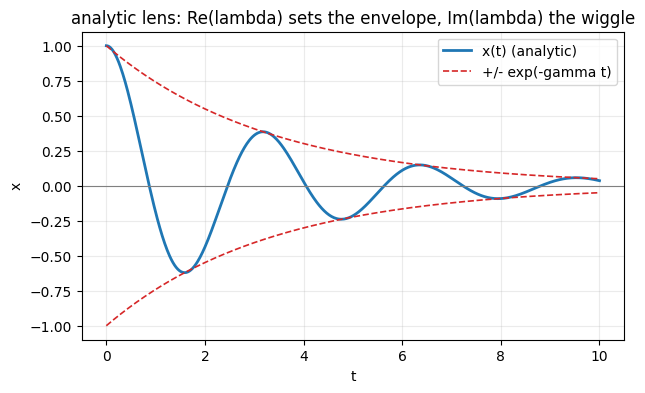

In [4]:
# The envelope exp(-gamma t) is Re(lambda) made visible.
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(t, X_exact[0], color="#1f77b4", lw=2, label="x(t) (analytic)")
ax.plot(t, np.exp(-gamma * t), color="#d62728", ls="--", lw=1.2, label="+/- exp(-gamma t)")
ax.plot(t, -np.exp(-gamma * t), color="#d62728", ls="--", lw=1.2)
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("t"); ax.set_ylabel("x"); ax.grid(alpha=0.25); ax.legend()
ax.set_title("analytic lens: Re(lambda) sets the envelope, Im(lambda) the wiggle")
plt.show()

## 4. 数値レンズ — 公式を知らないまま刻む

固有値分解を **使わずに**、RK4(06 章)で同じ軌道を作ります。
数値解法の値打ちは「公式が無い問題にも使えること」なので、ここでは
**解析解と比べて誤差がどう振る舞うか** を測ります。

RK4 は 4 次精度なので、刻み幅 $h$ を半分にすると誤差はおよそ $1/16$ になるはずです。

In [5]:
# Lens 2: RK4, no formula used. Then measure the order of accuracy.
f = systems.linear_system(A)
X_rk4 = solvers.rk4(f, x0, t)                      # shape (len(t), 2)

print("RK4 at t=10 :", np.round(X_rk4[-1], 6))
print("analytic    :", np.round(X_exact[:, -1], 6))
print("global error:", solvers.global_error(X_rk4, X_exact.T))

print("\n   h        global error     ratio")
prev = None
for n_steps in (100, 200, 400, 800, 1600):
    tt = np.linspace(0.0, t_end, n_steps + 1)
    exact = np.column_stack([expm(A * ti) @ x0 for ti in tt])
    err = solvers.global_error(solvers.rk4(f, x0, tt), exact.T)
    ratio = "-" if prev is None else f"{prev / err:6.1f}"
    print(f"{t_end / n_steps:7.5f}   {err:12.3e}   {ratio}")
    prev = err

RK4 at t=10 : [ 0.036  -0.0804]
analytic    : [ 0.036  -0.0804]
global error: 5.056695318028659e-08

   h        global error     ratio
0.10000      6.712e-05   -
0.05000      4.136e-06     16.2
0.02500      2.566e-07     16.1
0.01250      1.598e-08     16.1
0.00625      9.970e-10     16.0


比が 16 前後で並べば、実装が 4 次精度であることの実測的な確認になります。
比が 16 から外れるのは、誤差が丸め誤差の水準($10^{-14}$ 付近)に達したときです。

同じ刻み幅で Euler 法と並べると、次数の差がそのまま桁の差になって見えます。

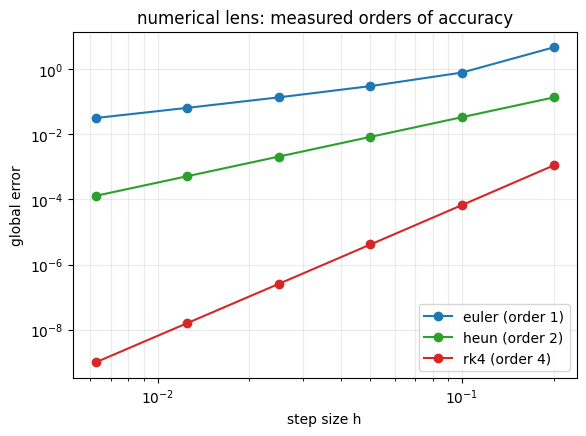

In [6]:
# Order of accuracy is a claim about slopes on a log-log plot, so plot it.
hs, errs = [], {"euler": [], "heun": [], "rk4": []}
for n_steps in (50, 100, 200, 400, 800, 1600):
    tt = np.linspace(0.0, t_end, n_steps + 1)
    exact = np.column_stack([expm(A * ti) @ x0 for ti in tt]).T
    hs.append(t_end / n_steps)
    for name, method in (("euler", solvers.euler), ("heun", solvers.heun), ("rk4", solvers.rk4)):
        errs[name].append(solvers.global_error(method(f, x0, tt), exact))

fig, ax = plt.subplots(figsize=(6.5, 4.5))
for name, color, order in (("euler", "#1f77b4", 1), ("heun", "#2ca02c", 2), ("rk4", "#d62728", 4)):
    ax.loglog(hs, errs[name], "o-", color=color, label=f"{name} (order {order})")
ax.set_xlabel("step size h"); ax.set_ylabel("global error"); ax.grid(alpha=0.25, which="both")
ax.legend(); ax.set_title("numerical lens: measured orders of accuracy")
plt.show()

## 5. 幾何レンズ — 解かずに、形だけを読む

3 つ目のレンズは **解を作りません**。ベクトル場と、固有値がトレース–行列式平面の
どこに落ちるかだけを見て、答えの **形** を言い当てます。

$p = \operatorname{tr}A = -2\gamma < 0$、$q = \det A = \omega^2 > 0$、判別式 $p^2 - 4q < 0$。
この 3 つで「安定渦状点(stable spiral)」が確定し、
**原点に渦を巻きながら吸い込まれる** ことが、解を一度も書かずに分かります。

classification without solving: stable spiral
p = tr(A) = -0.6  q = det(A) = 4.0  p^2 - 4q = -15.64


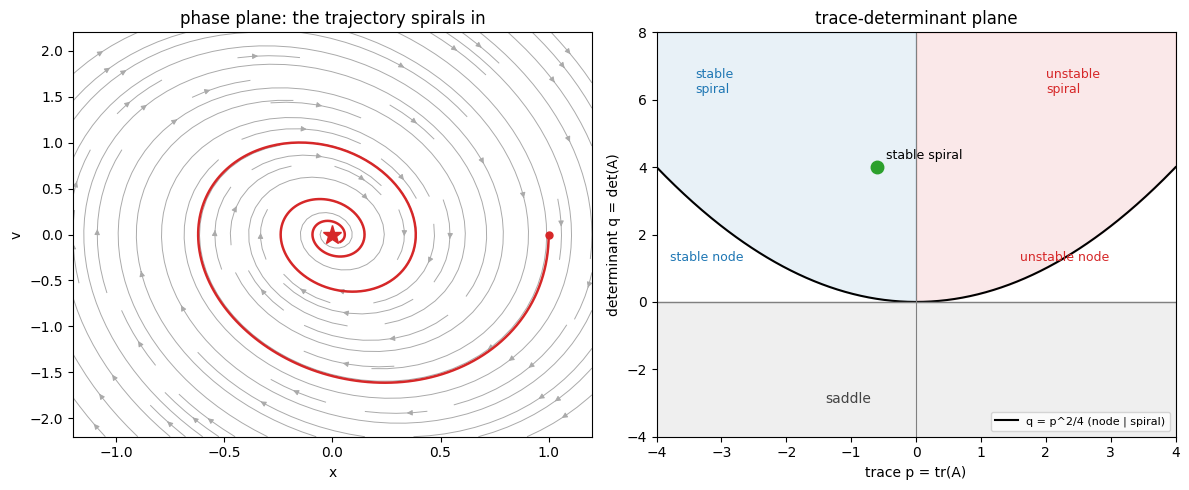

In [7]:
# Lens 3: read the answer's shape off the field and the trace-determinant plane.
print("classification without solving:", systems.classify_fixed_point(A))
print("p = tr(A) =", round(float(np.trace(A)), 4),
      " q = det(A) =", round(float(np.linalg.det(A)), 4),
      " p^2 - 4q =", round(float(np.trace(A) ** 2 - 4 * np.linalg.det(A)), 4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
plotting.phase_portrait(f, (-1.2, 1.2), (-2.2, 2.2), trajectories=[X_rk4],
                        fixed_points=[(0.0, 0.0)], ax=axes[0])
axes[0].set_ylabel("v"); axes[0].set_title("phase plane: the trajectory spirals in")
plotting.trace_determinant_diagram([A], ax=axes[1])
plt.tight_layout(); plt.show()

幾何レンズが「渦を巻いて落ちる」と言うとき、その根拠は
**固有値が複素共役ペアで実部が負** という一言です。虚部があるから回り、実部が負だから縮む。
解析レンズが $e^{(-\gamma \pm i\Omega)t}$ と書いた式と、同じことを図で言っています。

エネルギー $E = \tfrac{1}{2}(v^2 + \omega^2 x^2)$ を見ると、その「縮む」が単調な量として現れます。

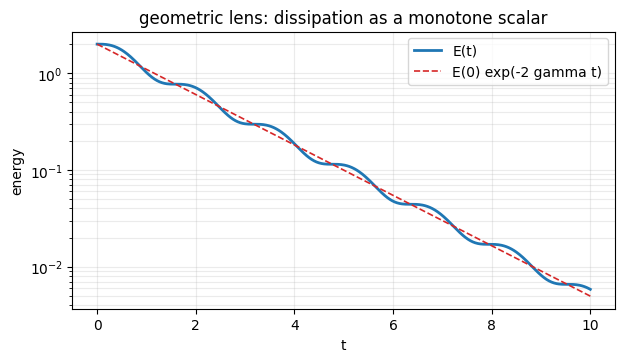

E is monotone decreasing: True


In [8]:
# The same statement as a scalar: energy decays like exp(-2 gamma t).
E = 0.5 * (X_exact[1] ** 2 + omega**2 * X_exact[0] ** 2)
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.semilogy(t, E, color="#1f77b4", lw=2, label="E(t)")
ax.semilogy(t, E[0] * np.exp(-2 * gamma * t), "--", color="#d62728", lw=1.2,
            label="E(0) exp(-2 gamma t)")
ax.set_xlabel("t"); ax.set_ylabel("energy"); ax.grid(alpha=0.25, which="both"); ax.legend()
ax.set_title("geometric lens: dissipation as a monotone scalar")
plt.show()
print("E is monotone decreasing:", bool(np.all(np.diff(E) < 0)))

## 6. 統合 — 3 つは同じ答え

解析解と数値解を重ね、幾何レンズが予言した形と突き合わせます。

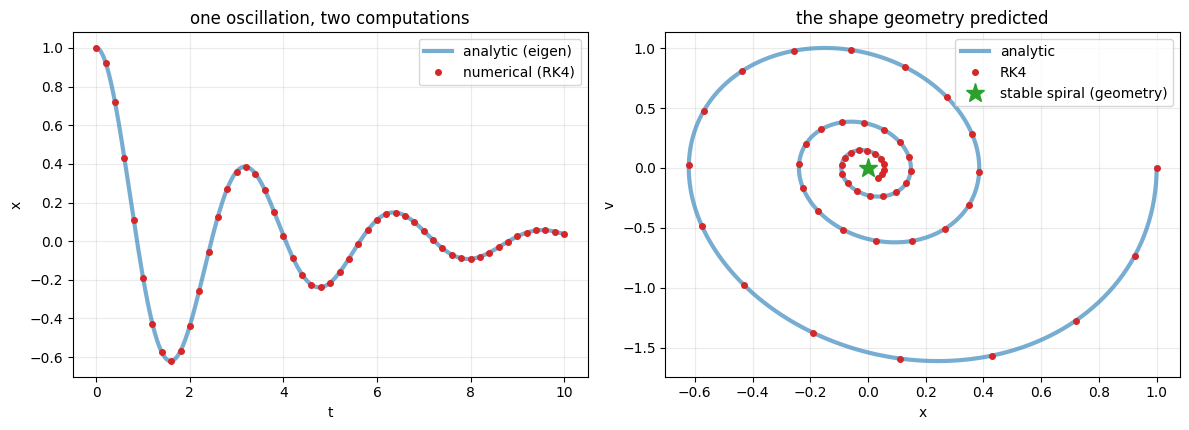

max |analytic - RK4| = 5.056695318028659e-08
state at t = 10      : [ 0.036  -0.0804]


In [9]:
# All three lenses, one picture.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
axes[0].plot(t, X_exact[0], color="#1f77b4", lw=3, alpha=0.6, label="analytic (eigen)")
axes[0].plot(t[::12], X_rk4[::12, 0], "o", ms=4, color="#d62728", label="numerical (RK4)")
axes[0].set_xlabel("t"); axes[0].set_ylabel("x"); axes[0].grid(alpha=0.25); axes[0].legend()
axes[0].set_title("one oscillation, two computations")

axes[1].plot(X_exact[0], X_exact[1], color="#1f77b4", lw=3, alpha=0.6, label="analytic")
axes[1].plot(X_rk4[::12, 0], X_rk4[::12, 1], "o", ms=4, color="#d62728", label="RK4")
axes[1].plot(0, 0, "*", color="#2ca02c", ms=14, label="stable spiral (geometry)")
axes[1].set_xlabel("x"); axes[1].set_ylabel("v"); axes[1].grid(alpha=0.25); axes[1].legend()
axes[1].set_title("the shape geometry predicted")
plt.tight_layout(); plt.show()

print("max |analytic - RK4| =", float(np.max(np.abs(X_exact.T - X_rk4))))
print("state at t = 10      :", np.round(X_exact[:, -1], 8))

### なぜ一致するのか — 一本の糸

3 つのレンズはどれも $A$ の **固有値** の話をしています。

| レンズ | 固有値がどこに現れるか |
|---|---|
| 解析 | 解そのもの $e^{\lambda t}$ の指数。実部が減衰、虚部が振動 |
| 数値 | 安定性の条件が $\lambda h$ で決まる。$\lvert\lambda\rvert$ が大きい系(剛性)ほど $h$ を小さく強いられる |
| 幾何 | 相図の形(節点か渦状点か鞍点か)は固有値の符号と虚部の有無で決まる |

> **線形の微分方程式を解くとは、固有モードに分解して、各モードを独立に進めることである。**

PDE 書 10 章のキャップストーンは、まったく同じ文をラプラシアンの固有関数(サイン波)について
述べたものです。**ODE の $A$ と PDE の $\partial_{xx}$ は、同じ役を演じています。**

## 7. 非線形では何が崩れるか

減衰振り子 $\ddot\theta + 2\gamma\dot\theta + \omega^2\sin\theta = 0$ に替えると、
**解析レンズだけが壊れます**。$\sin\theta$ を $\theta$ に線形化した式は、
小振幅では合いますが大振幅では合いません。数値レンズと幾何レンズはそのまま使えます。

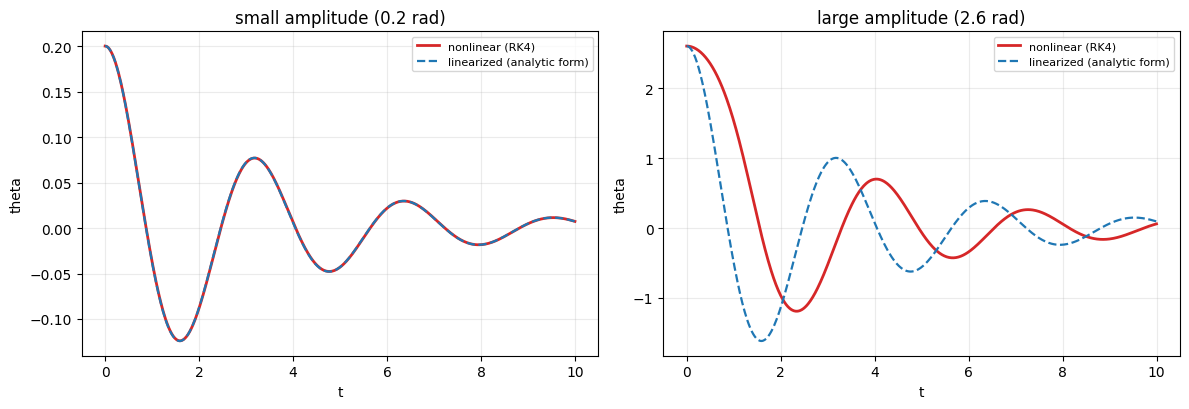

theta0 = 0.2: max |nonlinear - linearized| = 0.0007
theta0 = 2.6: max |nonlinear - linearized| = 2.1387


In [10]:
# Nonlinear pendulum vs its linearization, at small and large amplitude.
pend = systems.pendulum(omega=omega, gamma=gamma)
lin = systems.linear_system(A)          # the same A: the small-angle approximation

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharey=False)
for ax, theta0, label in ((axes[0], 0.2, "small amplitude (0.2 rad)"),
                          (axes[1], 2.6, "large amplitude (2.6 rad)")):
    y0 = np.array([theta0, 0.0])
    ax.plot(t, solvers.rk4(pend, y0, t)[:, 0], color="#d62728", lw=2, label="nonlinear (RK4)")
    ax.plot(t, solvers.rk4(lin, y0, t)[:, 0], color="#1f77b4", ls="--", lw=1.6,
            label="linearized (analytic form)")
    ax.set_xlabel("t"); ax.set_ylabel("theta"); ax.grid(alpha=0.25); ax.legend(fontsize=8)
    ax.set_title(label)
plt.tight_layout(); plt.show()

for theta0 in (0.2, 2.6):
    y0 = np.array([theta0, 0.0])
    gap = float(np.max(np.abs(solvers.rk4(pend, y0, t)[:, 0] - solvers.rk4(lin, y0, t)[:, 0])))
    print(f"theta0 = {theta0}: max |nonlinear - linearized| = {gap:.4f}")

大振幅では、非線形の振り子のほうが **周期が長く** なります
($\sin\theta < \theta$ なので復元力が弱い)。線形化した式にはこの効果が入りません。

一方で幾何レンズは生き残ります。原点まわりのヤコビ行列は $A$ そのものなので、
**十分近くでは** 分類がそのまま通用する — これが 04 章の線形化定理の意味です。

In [11]:
# The geometric lens survives: linearize at the fixed point and classify.
J = systems.jacobian(pend, np.array([0.0, 0.0]))
print("Jacobian of the pendulum at the origin:\n", np.round(J, 6))
print("classification:", systems.classify_fixed_point(J),
      "| same as the linear system:", systems.classify_fixed_point(A))
print("max |J - A| =", float(np.max(np.abs(J - A))))

Jacobian of the pendulum at the origin:
 [[ 0.   1. ]
 [-4.  -0.6]]
classification: stable spiral | same as the linear system: stable spiral
max |J - A| = 6.66577903984944e-13


## 関連教材

- [`../pde-book`](../pde-book/) — 10 章キャップストーン。同じ主張を熱拡散で述べたもの
- [`../../linear_algebra`](../../linear_algebra/) — 固有値・対角化(この一致の根拠)
- [`../../laplace`](../../laplace/) — 同じ線形 ODE を $s$ 領域で解く 4 つ目のレンズ
- 本書 03 章(連立系)・04 章(相図と安定性)・06 章(数値解法)

## Exercises

1. $\gamma$ を $0 \to 2 \to 3$ と変え、固有値・相図の分類・エネルギーの減り方が
   どう対応して変わるかを 3 レンズすべてで確かめよ($\gamma = \omega$ が臨界減衰)。
2. 数値レンズの表を Euler 法で作り直し、比が 16 ではなく 2 になることを確かめよ。
   刻み幅をいくつまで大きくすると発散するか、固有値との関係で説明せよ。
3. 強制振動 $\ddot x + 2\gamma\dot x + \omega^2 x = \cos(\Omega t)$ を
   `systems.harmonic_oscillator(omega, gamma, forcing=...)` で作り、
   $\Omega$ を掃引して振幅が最大になる点を数値で求めよ。それは $\omega$ とどれだけずれるか。

## Advanced Notes

- **剛性(stiffness)**: 固有値の実部が桁で離れている系では、速いモードが消えたあとも
  安定性のために $h$ が縛られる。陽的 RK4 では非効率で、陰的解法(BDF)に切り替える。
  PDE 書の線法で現れる $\alpha L$ は固有値が $-(N\pi)^2$ まで広がる典型例。
- **固有値が縮退する場合**: $\gamma = \omega$(臨界減衰)では $A$ が対角化できず、
  解に $t e^{\lambda t}$ が現れる(Jordan 標準形)。上の `np.linalg.eig` を使った
  モード分解はこの一点で破綻するので、`expm` を使うほうが安全。
- **保存系との違い**: $\gamma = 0$ なら固有値は純虚数で、エネルギーは保存され、
  相図は閉じた楕円になる。このとき RK4 の誤差はエネルギーの緩やかなドリフトとして現れ、
  長時間積分ではシンプレクティック法が好まれる。